# 05 — Feature Engineering

Apply the clinically-motivated composite features defined in `src/feature_engineering.py`, then persist the processed dataset (and train/val/test split) to `data/processed/` for the modelling notebooks.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd

from src.utils import RAW_DATA_PATH, PROCESSED_DIR, TARGET_COL, ensure_dirs, set_seed
from src.data_validation import load_raw_data
from src.preprocessing import clean_data, split_data
from src.feature_engineering import (
    engineer_features, ENGINEERED_FEATURE_NAMES,
    add_cognitive_composite, add_symptom_burden, add_cardiometabolic_risk,
    add_lifestyle_score, add_age_risk_interaction,
)

set_seed()
ensure_dirs()

df = load_raw_data(RAW_DATA_PATH)
df = clean_data(df)
print(f"After cleaning: {df.shape}")

[09:11:37] INFO - src.data_validation - Loaded raw data: 2149 rows x 35 columns


[09:11:37] INFO - src.preprocessing - Dropped non-predictive columns: ['PatientID', 'DoctorInCharge']


After cleaning: (2149, 33)


## 5.1 Engineered Features

Five new features are derived from the raw clinical columns, motivated directly by the EDA findings in notebook 04:

| Feature | Rationale |
|---|---|
| `CognitiveCompositeScore` | Combines MMSE, FunctionalAssessment, ADL (the three strongest univariate predictors from EDA) into one normalised 0–1 score, reducing noise from any single test. |
| `SymptomBurden` | Count of the 7 behavioural/cognitive symptom flags present — EDA showed each flag individually raises diagnosis rate, so a cumulative count should carry more signal than any one flag. |
| `CardiometabolicRiskScore` | Count of cardiometabolic risk flags (hypertension, diabetes, CVD, high LDL, low HDL, obesity) — EDA showed these are weak individually but may combine into a meaningful risk signal. |
| `LifestyleProtectiveScore` | Composite of physical activity, diet quality, sleep quality, and non-smoking status — a protective-direction composite. |
| `AgeFamilyHistoryInteraction` / `AgeCognitiveInteraction` | Age is a well-established AD risk multiplier — these interaction terms let tree models exploit age × risk-factor combinations more directly. |


In [2]:
df_before = df.copy()
df = engineer_features(df)
new_cols = [c for c in df.columns if c not in df_before.columns]
print(f"New engineered columns: {new_cols}")
df[new_cols].describe().T

[09:11:37] INFO - src.feature_engineering - Feature engineering added 6 new features (total columns now 39)


New engineered columns: ['CognitiveCompositeScore', 'SymptomBurden', 'CardiometabolicRiskScore', 'LifestyleProtectiveScore', 'AgeFamilyHistoryInteraction', 'AgeCognitiveInteraction']


,count,mean,std,min,25%,50%,75%,max
CognitiveCompositeScore,2149.0,0.499380,0.172250,0.045016,0.379112,0.505368,0.619687,0.956951
SymptomBurden,2149.0,1.339228,1.016554,0.000000,1.000000,1.000000,2.000000,5.000000
CardiometabolicRiskScore,2149.0,1.566775,1.042770,0.000000,1.000000,2.000000,2.000000,5.000000
LifestyleProtectiveScore,2149.0,0.552835,0.170732,0.060548,0.437822,0.562166,0.676130,0.986393
AgeFamilyHistoryInteraction,2149.0,0.122894,0.258985,0.000000,0.000000,0.000000,0.000000,1.000000
AgeCognitiveInteraction,2149.0,0.249889,0.181465,0.000000,0.100486,0.222765,0.367185,0.916132


## 5.2 Sanity Check: Do the Engineered Features Separate the Classes?

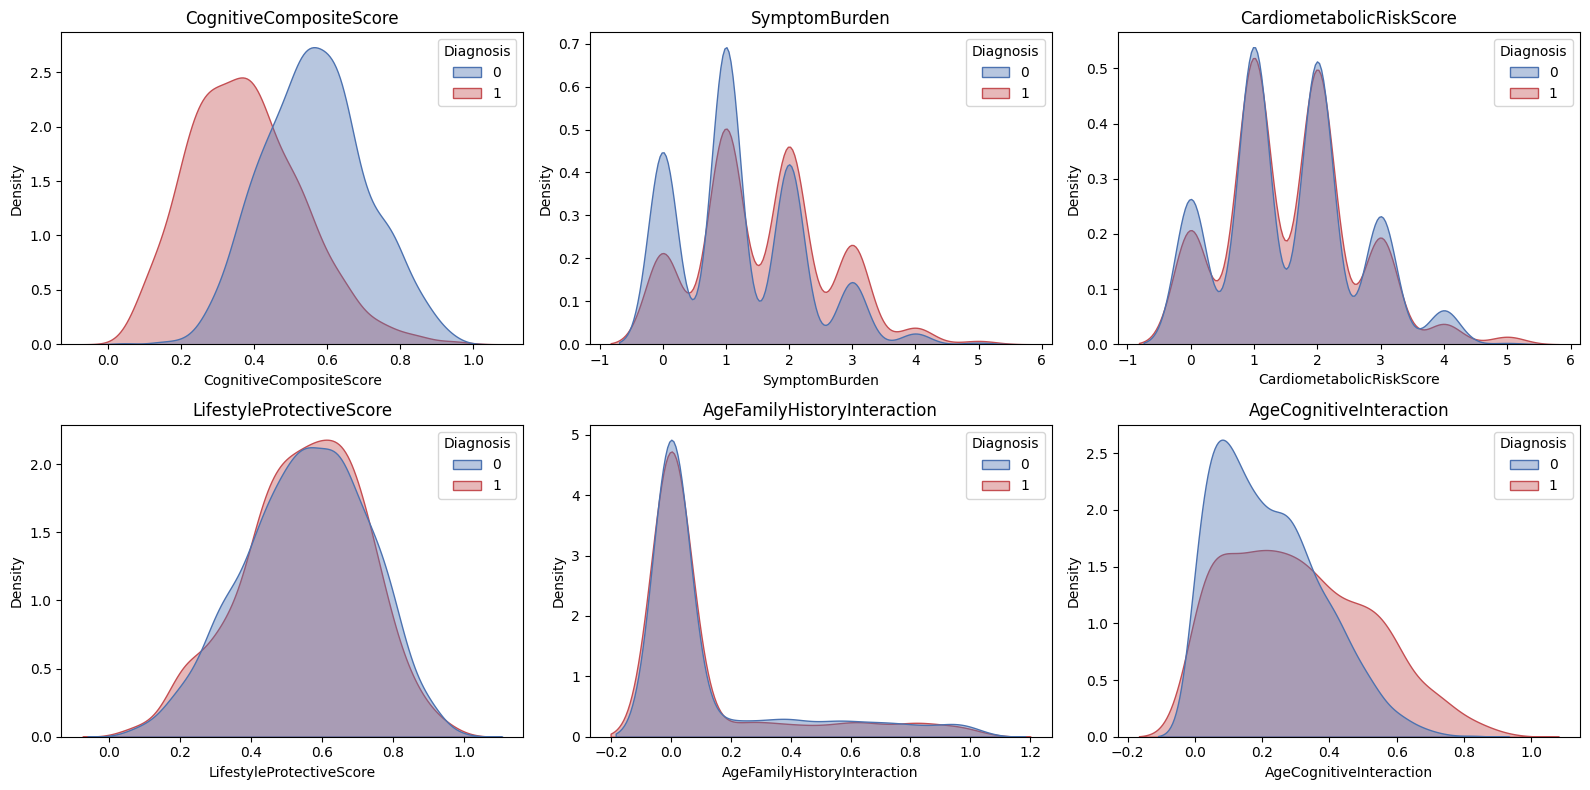

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(ENGINEERED_FEATURE_NAMES):
    sns.kdeplot(data=df, x=col, hue=TARGET_COL, fill=True, alpha=0.4, ax=axes[i],
                palette=['#4C72B0', '#C44E52'], common_norm=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../reports/engineered_features_distributions.png', dpi=110)
plt.show()

In [4]:
corr_with_target = df[ENGINEERED_FEATURE_NAMES + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print("Engineered features ranked by |correlation| with Diagnosis:")
corr_with_target

Engineered features ranked by |correlation| with Diagnosis:


CognitiveCompositeScore       -0.525729
AgeCognitiveInteraction        0.234757
SymptomBurden                  0.182135
AgeFamilyHistoryInteraction   -0.026186
LifestyleProtectiveScore      -0.014999
CardiometabolicRiskScore       0.004902
Name: Diagnosis, dtype: float64

**Observation:** `CognitiveCompositeScore` shows strong separation (as expected, since it's built from the three strongest predictors). `SymptomBurden` also separates cleanly, confirming the "combine weak-but-related flags into a count" strategy worked. The cardiometabolic and lifestyle composites show more modest but still non-trivial correlation — worth keeping in the model and letting tree-based feature importance in `06`/`07` confirm their real contribution rather than dropping them on correlation alone (composite scores can matter more via interactions than marginal correlation suggests).

## 5.3 Train / Validation / Test Split

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, test_size=0.2, val_size=0.1)

print(f"Train: {X_train.shape}, positive rate: {y_train.mean():.3f}")
print(f"Val:   {X_val.shape}, positive rate: {y_val.mean():.3f}")
print(f"Test:  {X_test.shape}, positive rate: {y_test.mean():.3f}")

[09:11:38] INFO - src.preprocessing - Split sizes -> train: 1504, val: 215, test: 430


Train: (1504, 38), positive rate: 0.354
Val:   (215, 38), positive rate: 0.353
Test:  (430, 38), positive rate: 0.353


## 5.4 Persist Processed Data

In [6]:
df.to_csv(PROCESSED_DIR / 'alzheimers_engineered.csv', index=False)

X_train.assign(**{TARGET_COL: y_train}).to_csv(PROCESSED_DIR / 'train.csv', index=False)
X_val.assign(**{TARGET_COL: y_val}).to_csv(PROCESSED_DIR / 'val.csv', index=False)
X_test.assign(**{TARGET_COL: y_test}).to_csv(PROCESSED_DIR / 'test.csv', index=False)

print("Saved processed files to data/processed/:")
for f in sorted(PROCESSED_DIR.glob('*.csv')):
    print(' -', f.name)

Saved processed files to data/processed/:
 - alzheimers_engineered.csv
 - test.csv
 - train.csv
 - val.csv


## 5.5 Feature Engineering Summary

- 6 new clinically-motivated composite/interaction features added (39 total columns from the original 33 predictive columns).
- `CognitiveCompositeScore` and `SymptomBurden` show the strongest separation by target, consistent with EDA.
- Data split into stratified train (70%) / validation (10%) / test (20%) sets and persisted to `data/processed/` for reproducible use across the remaining notebooks.
- Next: `06_Model_Development.ipynb` builds and compares candidate classifiers on this engineered feature set.